In [18]:
import pandas as pd
import json
from pathlib import Path
import numpy as np

In [49]:
def get_table_result(path_dir):

    res = Path(path_dir)
    rows = []
    for file in res.iterdir():
        if 'res.txt' in str(file):
            with open(file, 'r') as f:
                js = json.load(f)
                js['name'] = file.name[16:-8]
                rows.append(js)

    df = pd.DataFrame(rows)
    r = df.set_index('name')
    return r
    

df_1 = get_table_result('./result_1')
df_2 = get_table_result('./result_2')
df_3 = get_table_result('./result_3')

In [60]:
new = (df_1+df_2+df_3)/3
new_2 = ((df_1-new)**2+(df_2-new)**2+(df_3-new)**2)/2
# new = (df_1+df_2)/2
new.sort_values(['threshold_0.5 (all)'],ascending=False).style.highlight_max()
# new.to_excel('res.xlsx')
# new.to_csv('res.csv')
new[[
       'threshold_0.95 (1)',  'threshold_0.95 (2)',
        'threshold_0.95 (3)', 'threshold_0.95 (4)',  'threshold_0.95 (5)',
       'threshold_0.5 (all)', 'threshold_0.95 (all)', 
        'mAP (all)', 'mAP (seg)', 'mAP (text)', 'mAP (title)', 'mAP (list)', 'mAP (table)', 'mAP (figure)']].style.highlight_max()

new['threshold_0.95 (mean)'] = new[['threshold_0.95 (1)',  'threshold_0.95 (2)',
        'threshold_0.95 (3)', 'threshold_0.95 (4)',  'threshold_0.95 (5)']].mean(axis=1,)
new[['threshold_0.95 (mean)','threshold_0.95 (all)', 'mAP (all)', 'mAP (seg)']].sort_values(['threshold_0.95 (mean)'],ascending=False).style.highlight_max()

,threshold_0.95 (mean),threshold_0.95 (all),mAP (all),mAP (seg)
name,,,,
conjugate_tag_nolp,0.638957,0.642568,0.300170,0.465827
conjugate_tag_lp,0.626937,0.646024,0.275739,0.460133
plus_gnn_conv_nolp,0.593249,0.631664,0.277839,0.444598
plus_gnn_tag_lp,0.591317,0.641426,0.264554,0.461340
base_tag_nolp,0.576332,0.620591,0.244909,0.428036
base_tag_lp,0.567382,0.647903,0.232854,0.462250
base_conv_nolp,0.558601,0.610890,0.244476,0.424087
conjugate_gat_nolp,0.555736,0.636836,0.243064,0.461076
conjugate_conv_nolp,0.552128,0.610116,0.236428,0.425284


Найдено 180 записей.


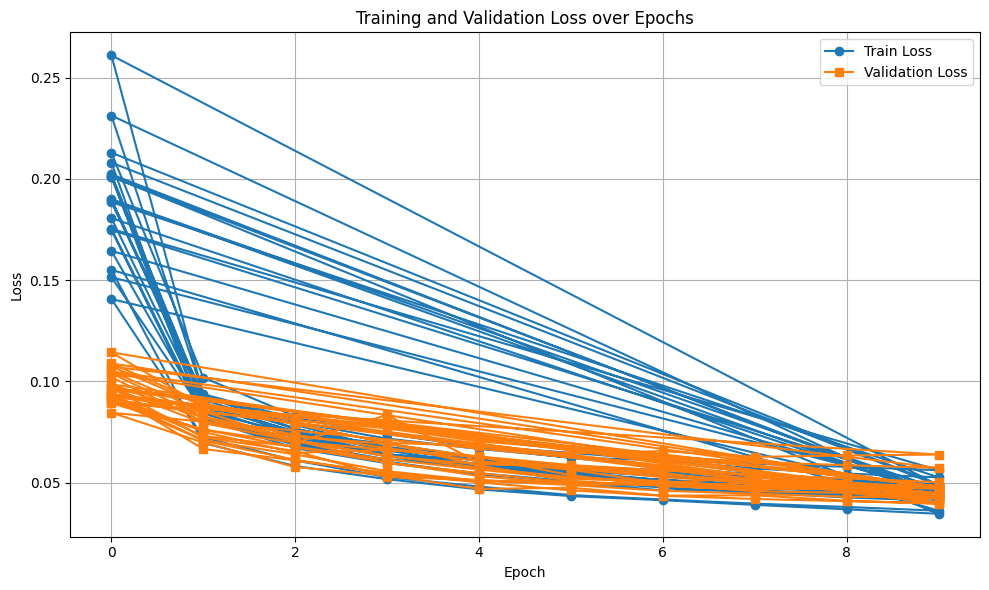

In [36]:
import re
import matplotlib.pyplot as plt

def parse_log(file_path):
    """
    Извлекает из лог-файла номер эпохи, train loss и val loss.
    Возвращает три списка: epochs, train_losses, val_losses.
    """
    epochs = []
    train_losses = []
    val_losses = []

    # Регулярное выражение для строки вида:
    # EPOCH #0	 0.20157574 (VAL: 0.10206552)
    pattern = re.compile(r'EPOCH #(\d+)\s+([\d.]+)\s+\(VAL:\s+([\d.]+)\)')


    eps = []
    tr = []
    val = []
    with open(file_path, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epoch = int(match.group(1))
                train_loss = float(match.group(2))
                val_loss = float(match.group(3))
                epochs.append(epoch)
                train_losses.append(train_loss)
                val_losses.append(val_loss)

    return epochs, train_losses, val_losses

def plot_losses(epochs, train_losses, val_losses):
    """
    Строит график тренировочного и валидационного loss в зависимости от эпохи.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, marker='o', label='Train Loss')
    plt.plot(epochs, val_losses, marker='s', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # При желании можно сохранить график:
    # plt.savefig('loss_plot.png')

if __name__ == "__main__":
    # Укажите путь к вашему лог-файлу
    log_file = "log_2026-05-27.txt"

    try:
        epochs, train_losses, val_losses = parse_log(log_file)
        if not epochs:
            print("В файле не найдено ни одной строки с данными обучения.")
        else:
            print(f"Найдено {len(epochs)} записей.")
            plot_losses(epochs, train_losses, val_losses)
    except FileNotFoundError:
        print(f"Файл '{log_file}' не найден. Проверьте путь.")

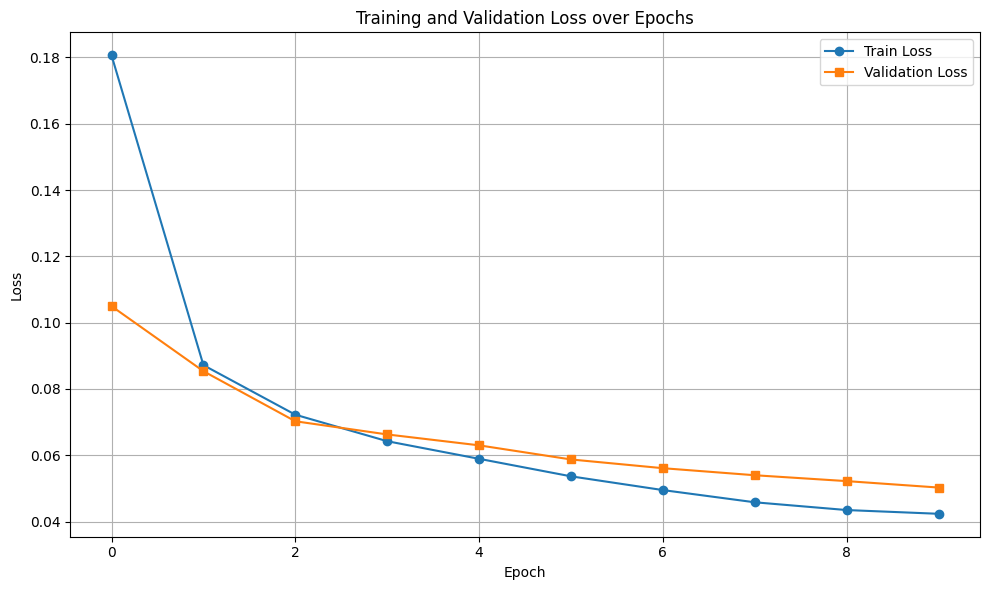

In [47]:
i = 17
plot_losses(epochs[i*10:(i+1)*10], train_losses[i*10:(i+1)*10], val_losses[i*10:(i+1)*10])

In [15]:
new_2**0.5

,mAP (all),mAP (seg),threshold_0.5 (all),threshold_0.95 (all)
name,,,,
base_conv_lp,0.004418,0.019498,0.013242,0.016151
base_conv_nolp,0.017498,0.027311,0.019717,0.023449
base_gat_lp,0.024689,0.005625,0.007114,0.007584
base_gat_nolp,0.062334,0.036751,0.032767,0.038428
base_tag_lp,0.043909,0.003048,0.001930,0.003110
base_tag_nolp,0.020360,0.019385,0.009559,0.017374
conjugate_conv_lp,0.011203,0.022390,0.009229,0.014699
conjugate_conv_nolp,0.026573,0.010859,0.013860,0.017245
conjugate_gat_lp,0.043564,0.006684,0.009021,0.017252


In [16]:
df = pd.read_csv('old_result/results.csv')
df[['name', 'mAP (all)',
       'mAP (seg)','threshold_0.5 (all)', 'threshold_0.95 (all)']]

,name,mAP (all),mAP (seg),threshold_0.5 (all),threshold_0.95 (all)
0,base_tag_lp,0.239080,0.547670,0.774606,0.702744
1,base_tag_nolp,0.231969,0.406458,0.684354,0.570595
2,base_conv_lp,0.154738,0.512087,0.734197,0.668689
3,base_conv_nolp,0.241734,0.521550,0.760667,0.685006
4,base_gat_lp,0.193374,0.499027,0.730312,0.658404
5,base_gat_nolp,0.240673,0.479729,0.715766,0.634213
6,plus_gnn_tag_lp,0.254727,0.560484,0.766359,0.707033
7,plus_gnn_tag_nolp,0.257638,0.530479,0.738766,0.675694
8,plus_gnn_conv_lp,0.272785,0.556338,0.767127,0.704927
9,plus_gnn_conv_nolp,0.195178,0.532422,0.756443,0.677621


In [39]:
dict_metric = {
    'threshold_0.5 (all)': None,
    'threshold_0.95 (all)': None,
    'mAP (seg)': None,
    'mAP (all)': None
}



for cal in dict_metric:
    tbl = df[['name', cal]]
    tbl[[' ', 'lr', ' ', 'bs']] = tbl['name'].str.split('_', expand=True)
    rez = tbl[['lr', 'bs', cal]]
    tbl = pd.DataFrame({key: rez[rez['lr']==key].set_index('bs')[cal] for key in rez['lr'].unique()})
    dict_metric[cal] = tbl

/tmp/ipykernel_162355/3309879830.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tbl[[' ', 'lr', ' ', 'bs']] = tbl['name'].str.split('_', expand=True)
/tmp/ipykernel_162355/3309879830.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tbl[[' ', 'lr', ' ', 'bs']] = tbl['name'].str.split('_', expand=True)
/tmp/ipykernel_162355/3309879830.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

In [47]:
dict_metric['threshold_0.5 (all)'].style.highlight_max()

,0.0100,0.0050,0.0010,0.0005
bs,,,,
1,0.055634,0.055635,0.758401,0.767218
8,0.055628,0.558259,0.779678,0.779113
64,0.723052,0.747474,0.779317,0.774989
128,0.685240,0.683954,0.765857,0.777484


In [48]:
dict_metric['threshold_0.95 (all)'].style.highlight_max()

,0.0100,0.0050,0.0010,0.0005
bs,,,,
1,0.050622,0.050622,0.688029,0.712750
8,0.050616,0.393992,0.727364,0.722335
64,0.651354,0.676247,0.716475,0.719949
128,0.607435,0.571259,0.688456,0.703493


In [49]:
dict_metric['mAP (all)'].style.highlight_max()

,0.0100,0.0050,0.0010,0.0005
bs,,,,
1,0.001469,0.001440,0.206761,0.228823
8,0.000000,0.078702,0.256513,0.293962
64,0.078416,0.153178,0.237606,0.213779
128,0.101198,0.152129,0.241218,0.229984


In [46]:
dict_metric['mAP (seg)'].style.highlight_max()

,0.0100,0.0050,0.0010,0.0005
bs,,,,
1,0.005639,0.005576,0.536134,0.575400
8,0.005758,0.252847,0.561198,0.571465
64,0.483072,0.523481,0.551716,0.525606
128,0.474606,0.412412,0.535694,0.545127
